# Test Plant Diseases detection App

In [1]:
!pip install opencv-python

## Importing Libraries

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## Getting Class names from the Validation Set

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17452 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

## Loading Model

In [4]:
cnn = tf.keras.models.load_model('trained_plant_disease_model1.keras')

C:\Users\HP\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Visualising and Performing Prediction on Single image

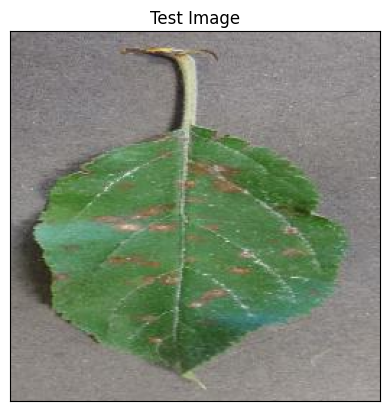

In [15]:
#Test Image Visualization
import cv2
image_path = 'test/AppleCedarRust2.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [16]:
from tensorflow.keras.preprocessing import image

## Image Processing on Test Image

In [17]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
input_arr.shape

(1, 128, 128, 3)

In [18]:
predictions = cnn.predict(input_arr)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[2.12124673e-09 8.29355216e-08 9.99920011e-01 1.68975695e-10
  3.17669308e-10 2.93837417e-07 5.04606745e-10 2.03422333e-05
  5.28703054e-11 2.91807511e-09 1.07569281e-13 1.18746430e-05
  3.29507337e-08 5.09971898e-10 5.30831323e-10 1.57032387e-09
  2.48649656e-07 6.46147927e-11 2.67532323e-05 2.44062868e-08
  1.17121184e-08 1.03062821e-08 7.10983772e-11 1.01277467e-11
  1.24504036e-11 1.73723494e-10 5.77091326e-12 4.58017576e-13
  2.01198927e-05 3.08113322e-08 3.61030872e-10 1.17107057e-09
  2.03327829e-07 2.77989480e-12 1.26684085e-08 2.38968428e-10
  6.41322995e-10 6.91970314e-10]]


In [19]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

2


## Displaying the disease prediction


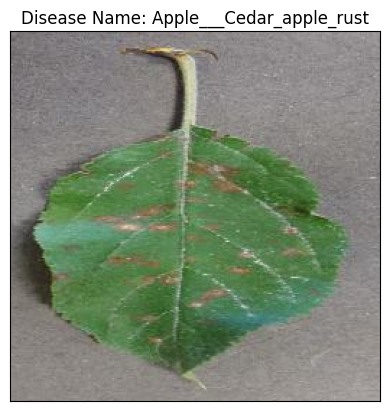

In [20]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

## Test 2

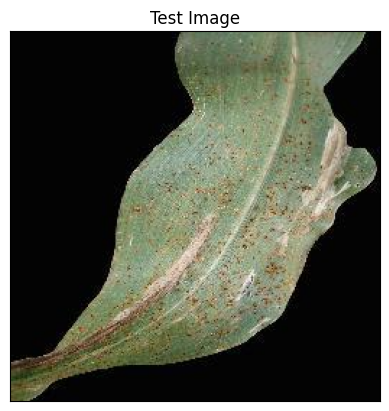

In [21]:
#Test Image Visualization
import cv2
image_path = 'test/CornCommonRust1.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [22]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
input_arr.shape

(1, 128, 128, 3)

In [25]:
predictions = cnn.predict(input_arr)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[2.9307736e-14 3.3924550e-15 3.3212850e-15 1.9640231e-16 3.3763301e-15
  2.8841406e-15 1.4594864e-18 8.8094983e-12 1.0000000e+00 3.6703022e-15
  8.7811177e-15 3.1246276e-18 6.9000528e-17 3.6387047e-19 3.0932574e-19
  1.8362304e-17 9.3989917e-19 5.2111878e-20 5.0562598e-18 8.6288066e-14
  8.3830894e-12 1.6412310e-20 2.7249579e-15 7.9164933e-20 2.4825910e-21
  4.7696730e-17 2.3634384e-18 6.6948178e-21 1.4778282e-19 1.7914717e-17
  3.0476974e-10 3.4685650e-21 4.5199014e-18 9.3562503e-25 3.0961970e-19
  8.6984049e-22 4.1142332e-21 1.7234085e-15]]


In [26]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

8


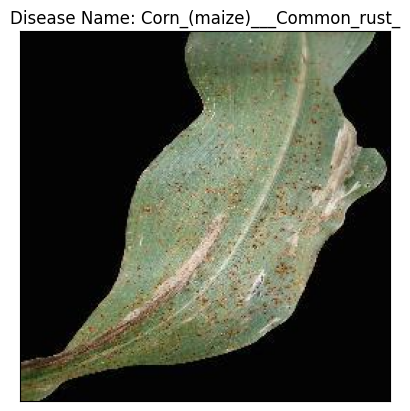

In [27]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

## Test 3

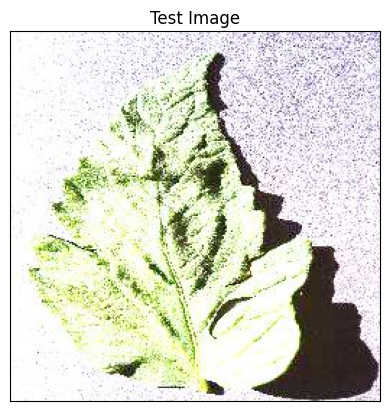

In [28]:
#Test Image Visualization
import cv2
image_path = 'test/TomatoHealthy4.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [29]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
input_arr.shape

(1, 128, 128, 3)

In [30]:
predictions = cnn.predict(input_arr)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[6.8714928e-16 2.6490464e-15 3.5042655e-15 1.8335213e-10 6.3583858e-17
  2.7952782e-11 1.9042306e-18 2.7298094e-13 4.8656712e-16 1.6335427e-16
  1.5109017e-15 8.8969098e-18 2.6603491e-14 3.3081494e-18 1.3539129e-17
  3.8566568e-18 3.5070203e-15 4.3628096e-15 1.9046095e-17 3.6152013e-14
  5.6798021e-14 8.0775285e-17 1.7436415e-14 2.9161626e-16 1.1131600e-15
  4.5928177e-09 9.1109527e-14 2.0473971e-17 8.0230563e-15 1.8309202e-15
  1.5799091e-11 8.1156257e-13 9.6420620e-14 6.1186008e-14 1.7048789e-06
  2.8888787e-17 6.2868323e-15 9.9999833e-01]]


In [31]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

37


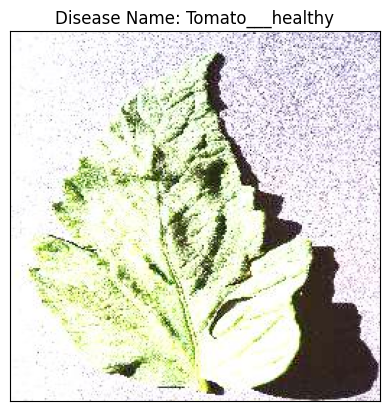

In [32]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()